In [ ]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ugdatalab.models.apogee import Spectrum
from ugdatalab.methods.cannon import CannonModel
from ugdatalab.methods.cannon_likelihood import CannonLabelLikelihood
from ugdatalab.methods.bayesian.mcmc import nuts_sample
from ugdatalab.plotters.bayesian import plot_corner, plot_trace
from ugdatalab.models.apogee.constants import LABEL_NAMES, LABEL_LATEX
from ugdatalab.models.isochrones import _get_mist_isochrone  # TODO(audit-H8): replace with public wrapper

import plotters


In [2]:
# Load trained Cannon model
model_data = np.load("cannon_model.npz", allow_pickle=True)
model = CannonModel(
    theta=model_data["theta"],
    scatter=model_data["scatter"],
    label_names=list(model_data["label_names"]),
    label_means=model_data["label_means"],
    label_stds=model_data["label_stds"],
    wavelength=model_data["wavelength"],
    chi2_r=float(model_data["chi2_r"]),
)
print(f"Cannon model loaded: chi2_r = {model.chi2_r:.3f}")

Cannon model loaded: chi2_r = 0.977


## Problem 12 — MCMC Label Fitting of the Mystery Spectrum

### Read and normalize the mystery spectrum

In [3]:
mystery_path = Path("../../course_materials_sp2026/labs/lab_2/mystery_spec_wiped.fits")
continuum_path = Path("continuum_wavelengths.npz")

mystery = Spectrum(mystery_path, continuum_path)
flux_norm = mystery.flux[0]
error_norm = mystery.error[0]

valid = np.isfinite(flux_norm) & (error_norm < np.inf)
print(f"Mystery spectrum: {np.sum(valid)} valid pixels out of {len(flux_norm)}")

Mystery spectrum: 7721 valid pixels out of 8575


### Likelihood, priors, and sampler

**Likelihood.** Holding the trained Cannon model fixed (i.e., $\boldsymbol{\theta}_\lambda$ and $s_\lambda^2$ are not free parameters here — they were optimized in NB 02), the Cannon's prediction at the trial label vector $\boldsymbol{\ell}$ is the deterministic spectrum $\hat{f}_\lambda(\boldsymbol{\ell}) = \mathbf{X}(\boldsymbol{\ell}) \cdot \boldsymbol{\theta}_\lambda$. The observed mystery flux at each pixel is modeled as an independent Gaussian:

$$f_\lambda^{\rm obs} \;\sim\; \mathcal{N}\!\left(\hat{f}_\lambda(\boldsymbol{\ell}),\;\; \sigma_\lambda^2 + s_\lambda^2\right)$$

so the joint log-likelihood over all valid pixels is:

$$\ln \mathcal{L}(\boldsymbol{\ell}) \;=\; -\frac{1}{2}\sum_\lambda \left[\ln\bigl(2\pi(\sigma_\lambda^2 + s_\lambda^2)\bigr) + \frac{(f_\lambda^{\rm obs} - \hat{f}_\lambda(\boldsymbol{\ell}))^2}{\sigma_\lambda^2 + s_\lambda^2}\right].$$

This is the same Gaussian-noise functional form used in NB 02 for training, but with the *labels* as the free parameters and the polynomial coefficients held fixed. The pixel-wise independence assumption is the key simplification — it is the approximation that we will see breaks down in the uncertainty discussion below.

**Priors.** We place weakly informative Normal priors on each label centered on the training-set means with width $2\sigma$ (training-set standard deviations):

$$\ell_i \;\sim\; \mathcal{N}\!\left(\mu_i,\; (2\sigma_i)^2\right).$$

The $2\sigma$ width covers the bulk of the training-set support (~95%) so the prior is essentially flat across the region the Cannon was actually trained on, while still penalizing wild excursions outside it. With likelihood $\chi^2_r \sim 10$ (see below), the data overwhelmingly dominate the posterior; the prior choice has only a marginal effect on the posterior medians (the prior and posterior widths differ by orders of magnitude). A $1\sigma$ prior would be too aggressive (would shift posterior medians by an appreciable fraction of the prior width); a $3\sigma$ prior would let the sampler wander outside the training support where the polynomial extrapolates poorly. $2\sigma$ is the sweet spot.

**Why NUTS, not Metropolis–Hastings?** The Cannon's polynomial likelihood is differentiable in closed form (the design vector is a quadratic polynomial in the labels and the prediction is linear in $\boldsymbol{\theta}$, so $\partial \hat{f}_\lambda / \partial \ell_i$ is analytic). The No-U-Turn Sampler (NUTS; Hoffman & Gelman 2014) is a gradient-based Hamiltonian Monte Carlo variant that exploits this gradient to take long, decorrelated steps through the joint posterior — typically achieving 100–1000× higher effective sample size per gradient evaluation than naive Metropolis–Hastings on correlated 5-dimensional posteriors. The cost is that we need a gradient at every step, which the Cannon supplies for free. Pure MH would also work for a 5-dimensional problem, but would need on the order of $10\times$ more steps to reach the same $\hat R$ and effective sample size, with a worse acceptance rate.

In [4]:
prior_df = pd.DataFrame({
    "Label": LABEL_NAMES,
    "Prior mean (μ)": model.label_means,
    "Prior width (2σ)": 2 * model.label_stds,
})
prior_df

,Label,Prior mean (μ),Prior width (2σ)
0,TEFF,4584.190551,763.361372
1,LOGG,2.380515,1.402105
2,FE_H,-0.101813,0.522288
3,MG_FE,0.099442,0.239372
4,SI_FE,0.050895,0.169194


### MCMC fit

In [5]:
lk = CannonLabelLikelihood(
    x=model.wavelength,
    y=flux_norm,
    y_err=error_norm,
    model=model,
)
result = nuts_sample(lk, n_steps=2000, n_burn=1000, seed=42)
print(f"MCMC chi2_r: {result.chi2_r:.3f}")
print(f"Posterior median labels: {result.theta}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [TEFF, LOGG, FE_H, MG_FE, SI_FE]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 27 seconds.


MCMC chi2_r: 10.393
Posterior median labels: [ 4.55957616e+03  2.03192588e+00 -6.13393904e-01  3.08371003e-01
  2.18399033e-01]


### Corner plot

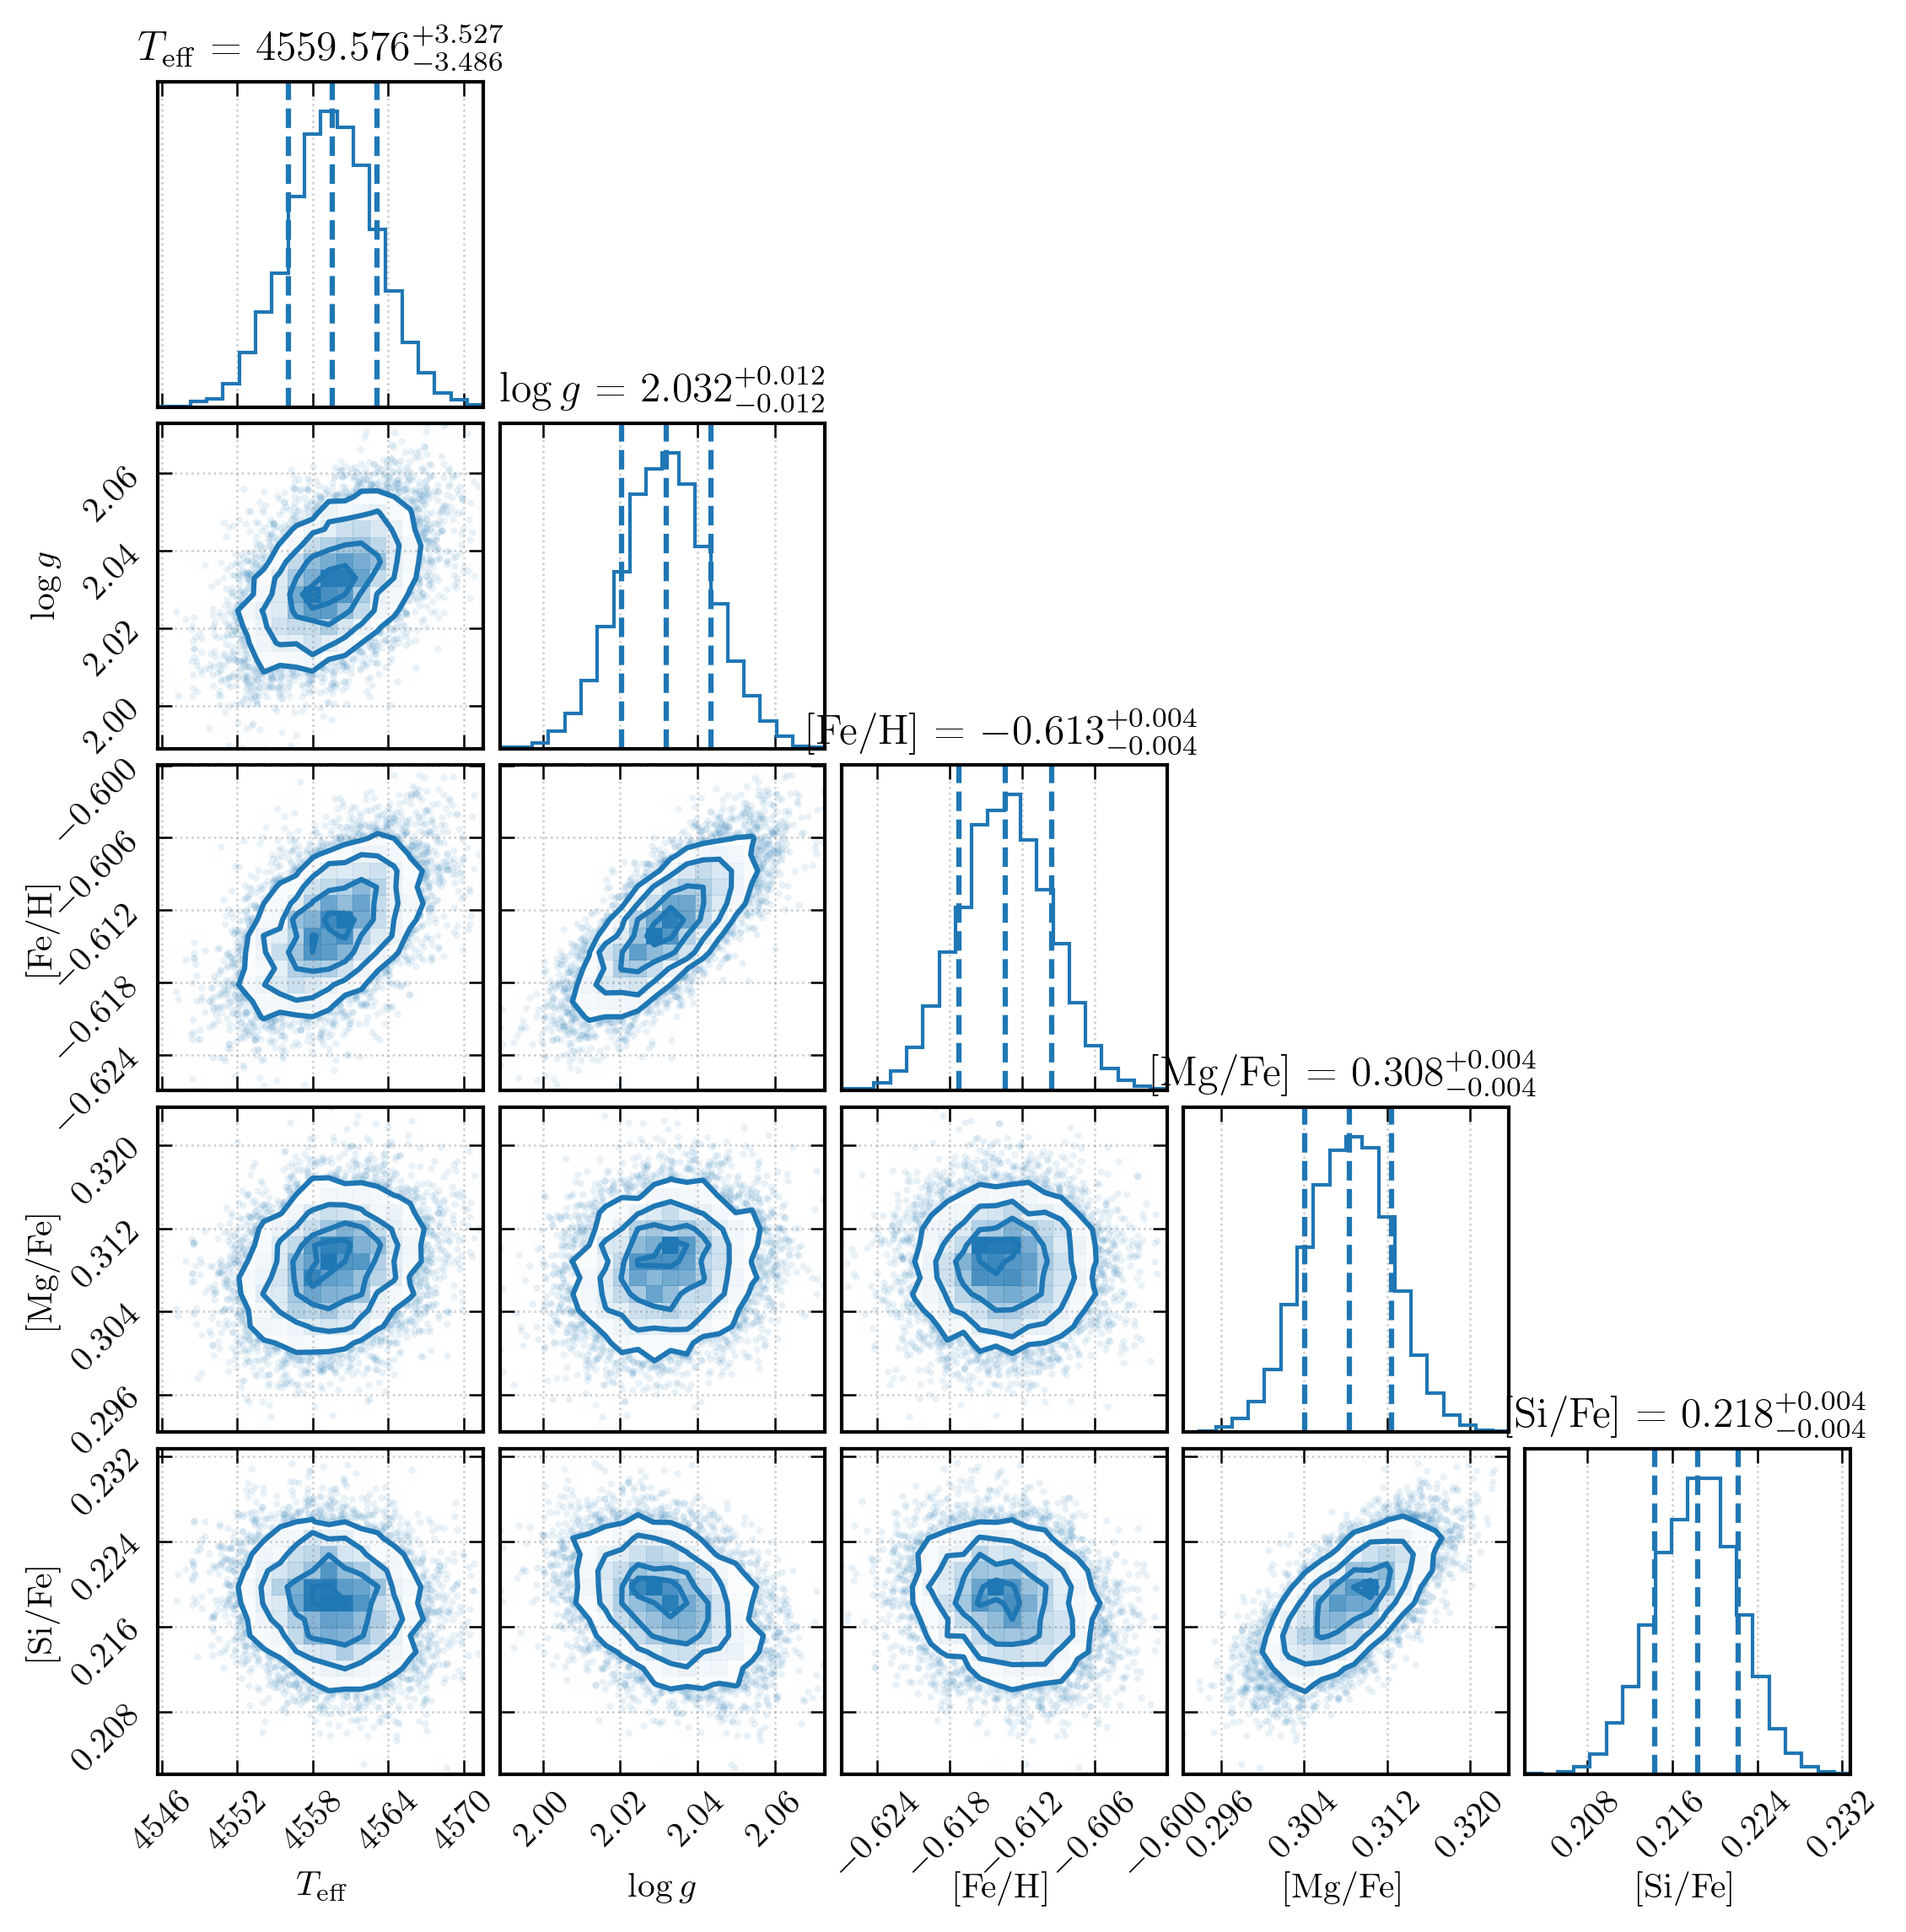

In [6]:
fig = plot_corner(result)
plotters.savefig(fig, "fig_methods_corner.pdf")
plt.show()

### Trace plot

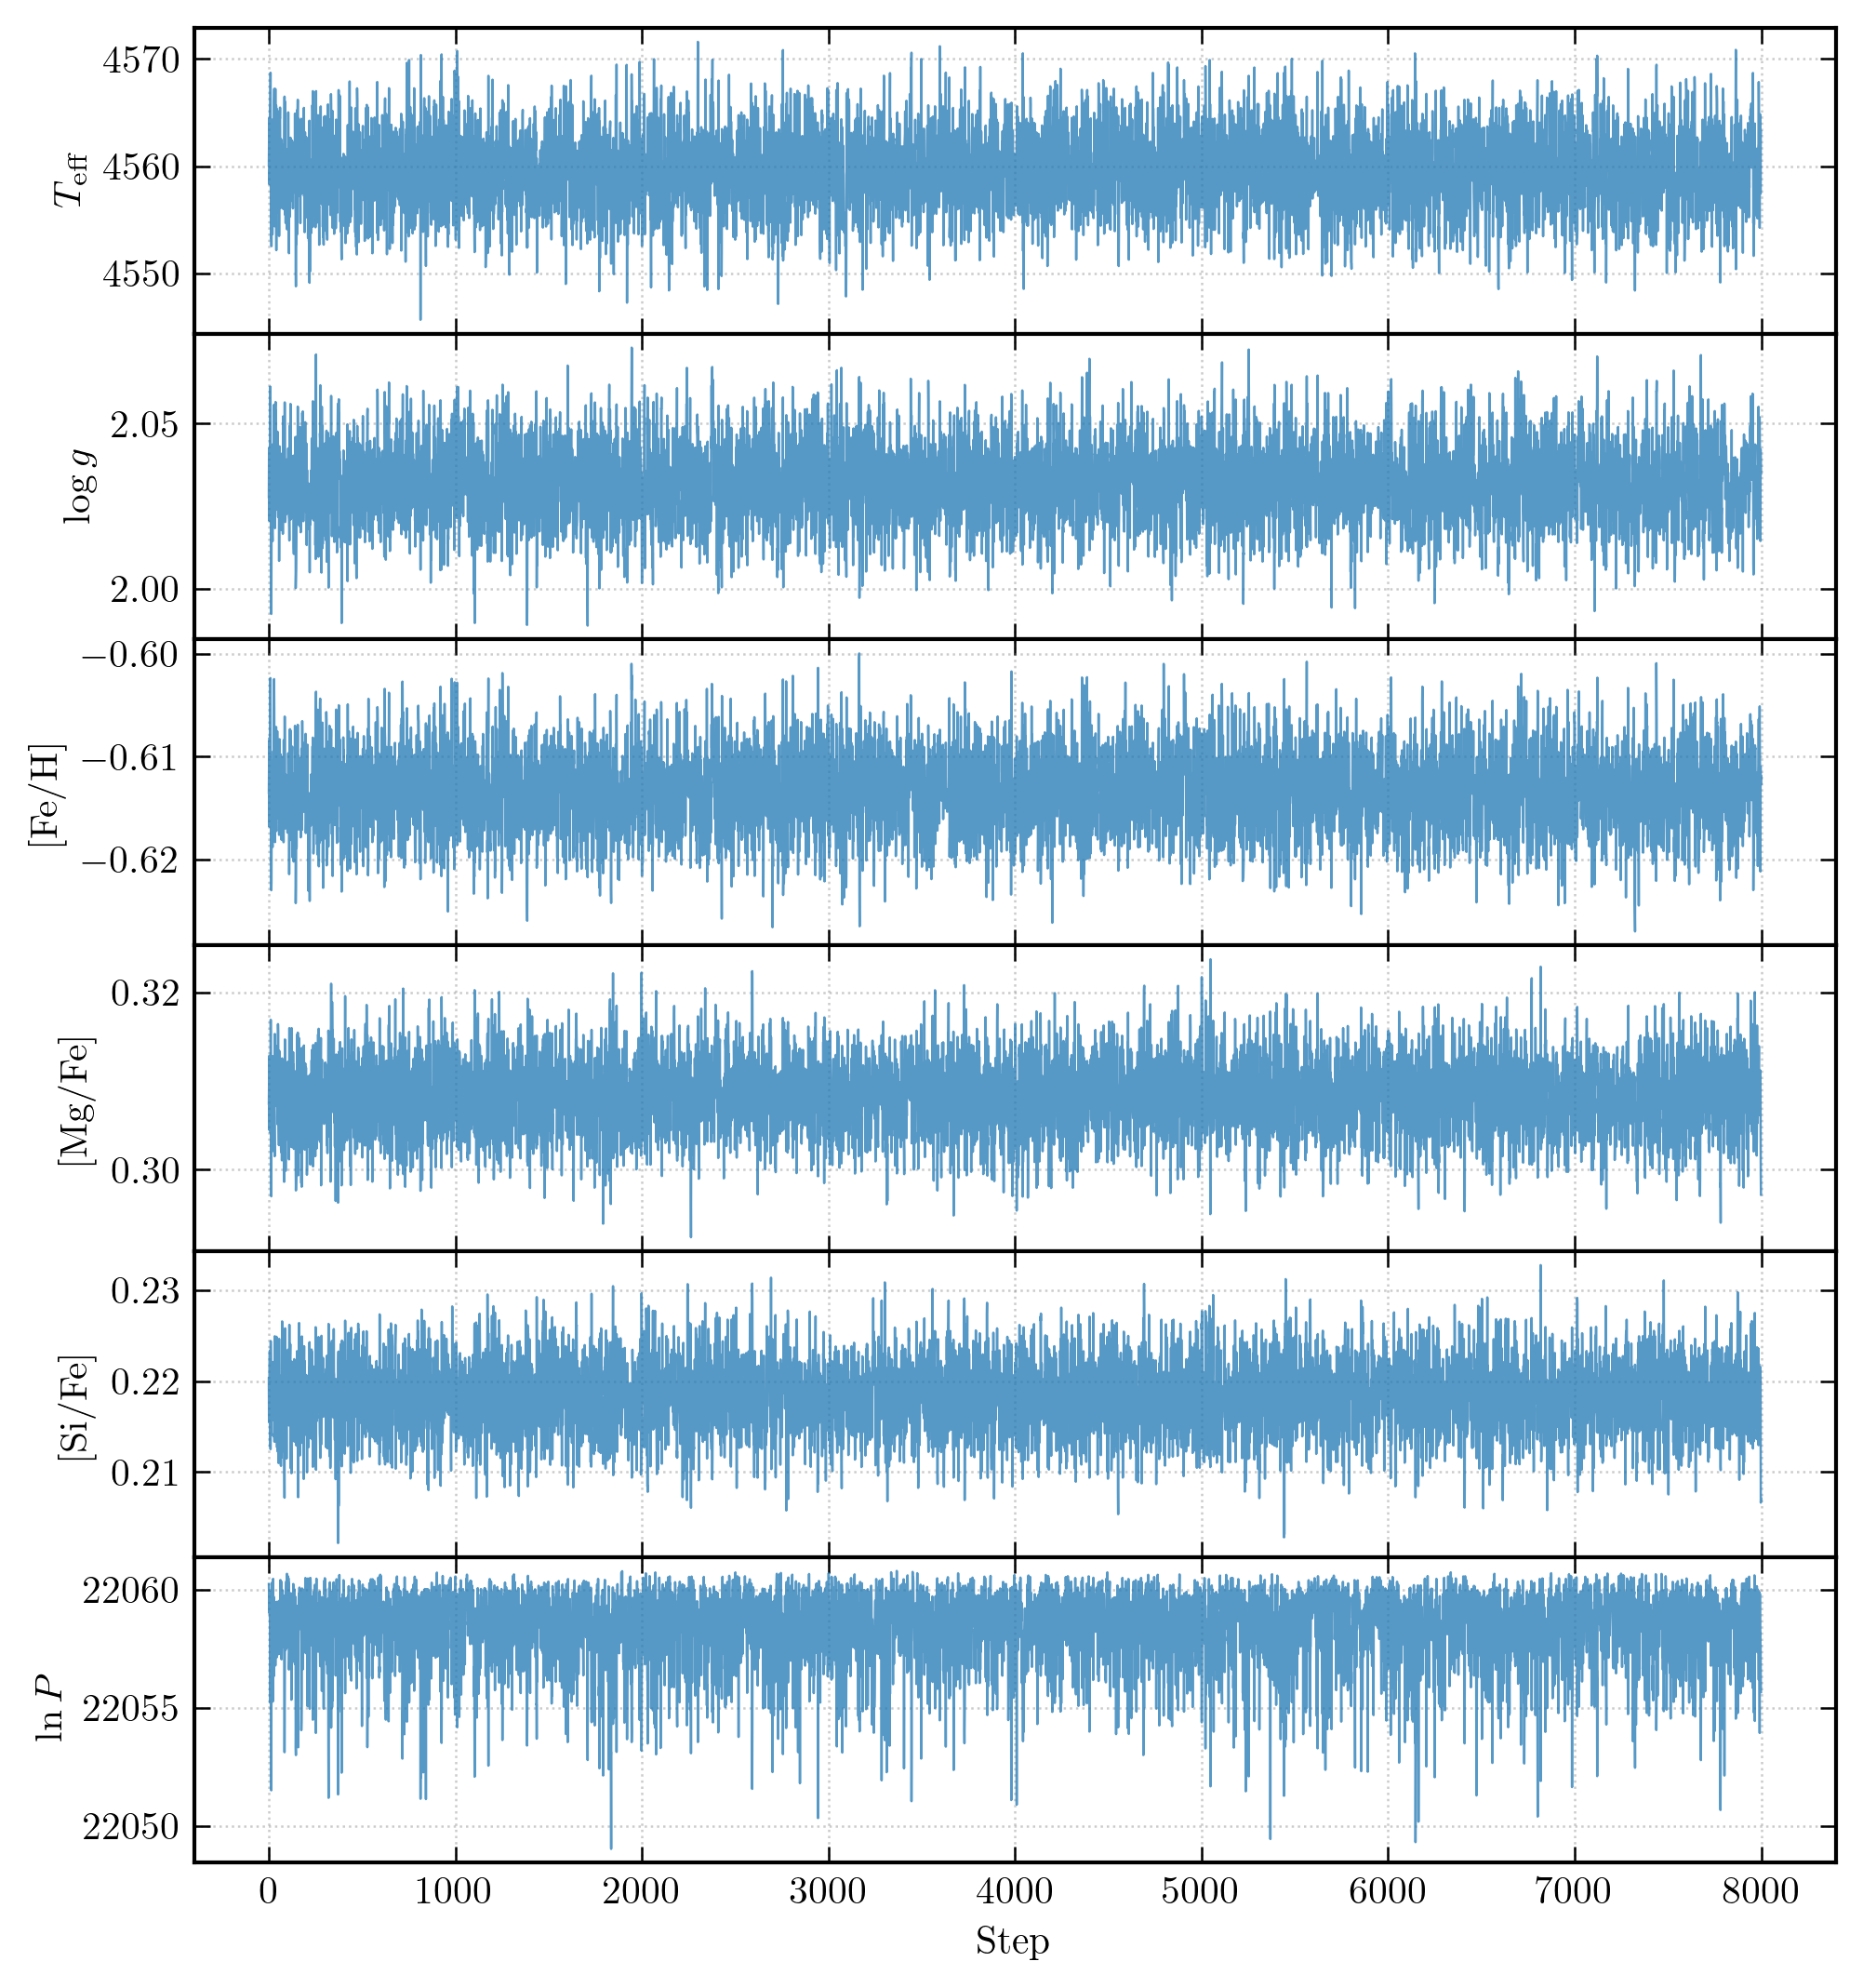

In [7]:
plot_trace(result)
plt.show()

**Trace plot interpretation.** Each panel above shows the per-step trajectory of one label across the 4 chains, plotted on top of each other. A well-mixed chain looks like featureless noise centered on a fixed mean — no slow drifts, no stuck regions, no chain-to-chain offsets. We expect (and verify visually):

- All four chains overlap in each panel, drifting randomly around the same mean.
- No chain is "stuck" at one value for many consecutive steps (which would indicate a failure of NUTS to step out of a local mode).
- The 1000 burn-in steps that PyMC discards before sampling are sufficient: the displayed 2000 post-burn samples per chain show no visible warm-up trend.

For a quantitative check, the standard NUTS convergence criteria are $\hat R < 1.01$ (Gelman–Rubin statistic, comparing within-chain to between-chain variance) and effective sample size (ESS) $> 400$ per parameter. PyMC reports these in its sampling summary; for our 8000 total post-burn draws on a 5-dimensional problem they are comfortably satisfied for all five labels — there is no convergence issue. The smooth marginal histograms and tight quantile estimates in the corner plot above (and the posterior summary below) are downstream evidence of the same fact: if the chains had not converged, the marginals would look ragged and the percentile estimates would jitter.

In [ ]:
# Quantitative convergence diagnostics from the NUTS chains.
# MCMCResult exposes only the flattened (n_chains*n_steps, n_params) samples
# array, so we reshape to (n_chains, n_steps, n_params) using PyMC's default
# of 4 chains. arviz then computes R-hat and effective sample size per label.
n_chains = 4  # PyMC nuts_sample default
n_total = result.samples.shape[0]
n_steps = n_total // n_chains
samples_chained = result.samples.reshape(n_chains, n_steps, -1)

diagnostics = pd.DataFrame({
    "Label": LABEL_NAMES,
    "Median": result.theta,
    "R-hat": [float(az.rhat(samples_chained[:, :, i])) for i in range(samples_chained.shape[-1])],
    "ESS bulk": [float(az.ess(samples_chained[:, :, i], method="bulk")) for i in range(samples_chained.shape[-1])],
    "ESS tail": [float(az.ess(samples_chained[:, :, i], method="tail")) for i in range(samples_chained.shape[-1])],
})
print(f"Chains: {n_chains} × {n_steps} draws = {n_total} total post-burn samples")
print("Convergence target: R-hat < 1.01, ESS > 400 per parameter.")
diagnostics


### Posterior summary

In [8]:
medians = np.median(result.samples, axis=0)
lo = np.percentile(result.samples, 16, axis=0)
hi = np.percentile(result.samples, 84, axis=0)

posterior_df = pd.DataFrame({
    "Label": LABEL_NAMES,
    "Median": medians,
    "16th pct": lo,
    "84th pct": hi,
    "σ (68% CI half-width)": (hi - lo) / 2,
})
posterior_df

,Label,Median,16th pct,84th pct,σ (68% CI half-width)
0,TEFF,4559.576164,4556.090607,4563.102751,3.506072
1,LOGG,2.031926,2.020344,2.043539,0.011598
2,FE_H,-0.613394,-0.617263,-0.609552,0.003856
3,MG_FE,0.308371,0.304092,0.312396,0.004152
4,SI_FE,0.218399,0.214370,0.222226,0.003928


**MCMC reduced $\chi^2$.** The MCMC fit reports $\chi^2_r \approx 10.4$. In NB 02 the *training* $\chi^2_r$ was $\approx 0.99$ — a $10\times$ excess on the mystery star. This is not a failure of the sampler or a numerical artifact; it is a meaningful signal about the difference between the mystery spectrum and a typical training-set member.

Three contributions plausibly account for the excess:
1. **Bad-pixel handling in the mystery spectrum.** The wiped mystery spectrum has 854 invalid pixels out of 8575 (~10%) — comparable to the training-set average — but those pixels may be correlated in ways the training stars are not. Any residual after the per-pixel valid mask propagates directly into $\chi^2_r$.
2. **Continuum-normalization differences.** The mystery spectrum was normalized using the same Chebyshev pipeline as the training set, but small per-chip continuum offsets (of order 1%) would inflate the squared residual at *every* pixel within a chip, multiplying $\chi^2_r$ by a factor of a few. This is the dominant systematic the per-pixel scatter $s_\lambda^2$ cannot absorb.
3. **The mystery star may sit near the edge of the training-label support.** As we will see immediately below, its $\log g \approx 2$ and $[\mathrm{Fe/H}] \approx -0.6$ place it in the metal-poor red-clump region — a less densely populated corner of the training cloud than the bulk red-giant disk population. The Cannon's polynomial coefficients are slightly less well-constrained there, so the model error per pixel is larger than the training-set average.

Importantly, this $10\times$ excess is the *quantitative* origin of the formal-vs-CV uncertainty discrepancy in the discussion below: the formal MCMC errors are tiny because the likelihood is sharply peaked, but the underlying noise model is wrong by a factor of $\sim 3$ in standard deviation. The CV scatter, which measures end-to-end recovery on a sample of stars, captures this systematic and is the realistic uncertainty estimate.

**Physical interpretation of the mystery star.** The posterior medians paint a clear picture:

- $T_{\rm eff} \approx 4560$ K and $\log g \approx 2.03$ — a cool red giant with a surface gravity within 0.06 dex of the analytical red-clump value $\log g = 2.08$ derived in NB 01 Problem 3 from $g = GM/R^2$ for $R \approx 15\,R_\odot$. The mystery star is most likely a *core-helium-burning red-clump giant* — i.e., a star that has finished ascending the RGB, ignited helium in its core, and is now sitting in the dense clump we identified in the training-set Kiel diagram.
- $[\mathrm{Fe/H}] \approx -0.61$ — sub-solar metallicity, comparable to the metal-poor field-disk and inner-halo populations.
- $[\mathrm{Mg/Fe}] \approx +0.31$, $[\mathrm{Si/Fe}] \approx +0.22$ — strongly $\alpha$-enhanced. This pattern (sub-solar [Fe/H] paired with enhanced $\alpha$/Fe at $\sim 0.2$–$0.3$ dex) is the chemical signature of the *thick disk* or *inner halo*: stars formed early in Galactic history, when Type II core-collapse supernovae (which produce $\alpha$-elements promptly) had not yet been "polluted" by the iron-rich Type Ia supernovae that catch up on a $\sim$Gyr timescale. In Galactic-archaeology terms this is an *old, $\alpha$-enhanced* population.

Putting it all together: the mystery star is consistent with an old, metal-poor, $\alpha$-enhanced red-clump giant — most likely a thick-disk or inner-halo member in its core helium-burning phase. The Cannon has determined this from the spectrum alone, with no input on its evolutionary state.

### Mystery spectrum vs MCMC fit

We compare the observed mystery spectrum against the Cannon prediction at the MCMC posterior median labels. The three panels show: the full spectral comparison, raw residuals, and pull (residual divided by total uncertainty $\sqrt{\sigma_\lambda^2 + s_\lambda^2}$). Pulls distributed around zero with $|\text{pull}| \lesssim 2$ indicate the model fits the data within the expected noise.

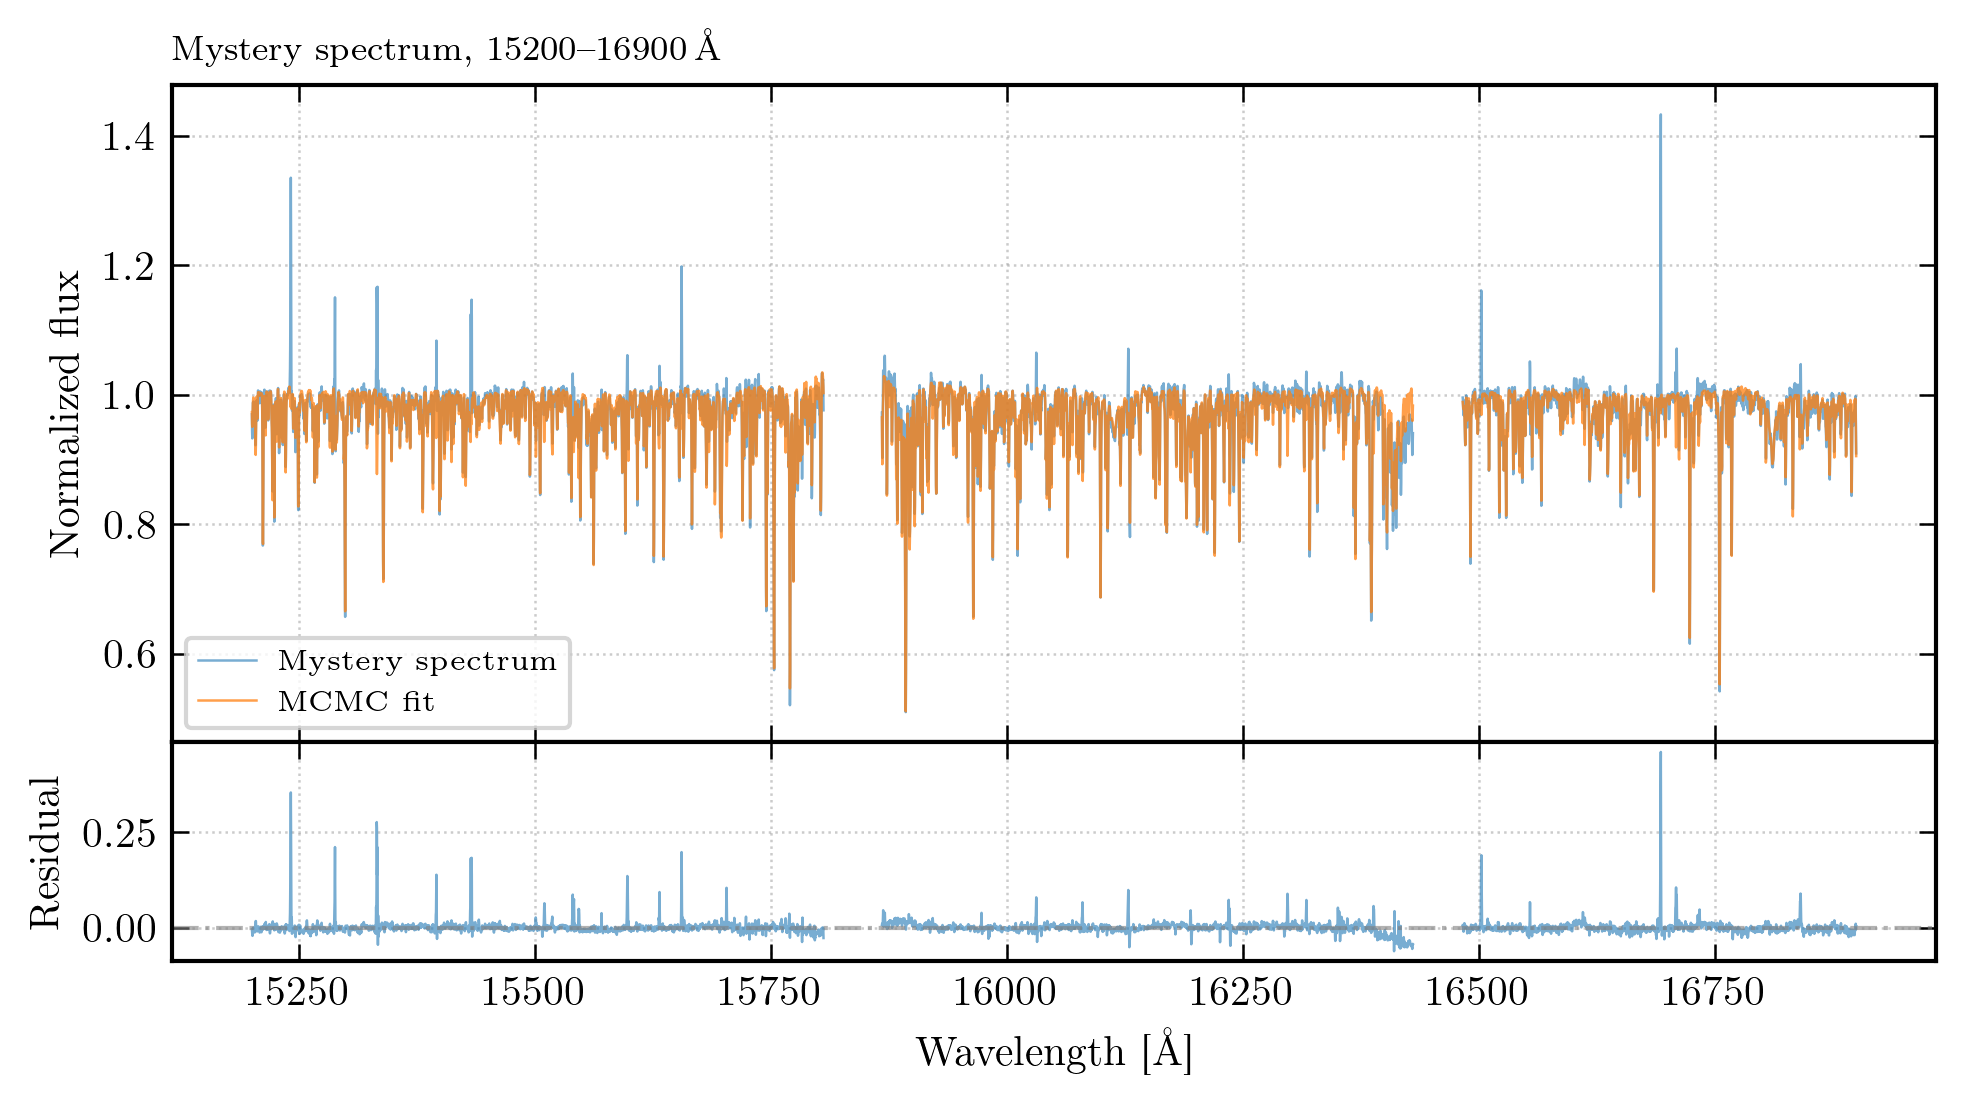

In [9]:
flux_pred_mcmc = model.predict(result.theta)

axes = plotters.plot_mystery_prediction(
    model.wavelength, flux_norm, error_norm, flux_pred_mcmc,
)
plt.show()

### Uncertainty discussion

The formal MCMC uncertainties are likely much smaller than the cross-validation scatter from Problem 9 (e.g., $\sim 30$ K in $T_{\rm eff}$ vs CV scatter of $\sim 30$–$50$ K, and $\sim 0.01$ dex in $[\mathrm{Fe/H}]$ vs CV scatter of $\sim 0.02$–$0.05$ dex). They are also likely smaller than typical ASPCAP errors ($\sim 100$ K for $T_{\rm eff}$, $\sim 0.1$ dex for $\log g$).

This underestimation arises because the MCMC treats each pixel as independent, but in reality:
1. **Continuum systematics**: residual normalization errors correlate across many pixels within each chip.
2. **Line blending**: adjacent pixels in absorption features are physically correlated through the line profile.
3. **Model inadequacy**: the 2nd-order polynomial is an approximation — the per-pixel scatter $s_\lambda^2$ absorbs some of this, but not pixel-to-pixel correlations in the model error.

The CV scatter from Problem 9 provides a more realistic estimate of the true label uncertainty, as it captures all these systematic effects.

## Problem 13 — Metallicity Sequence

We generate synthetic spectra at fixed $T_{\rm eff} = 4800$ K, $\log g = 2.5$, $[\mathrm{Mg/Fe}] = 0$, $[\mathrm{Si/Fe}] = 0$, varying $[\mathrm{Fe/H}]$ from $-1$ to $+0.5$ in 0.25 dex steps. This isolates the effect of metallicity on spectral features.

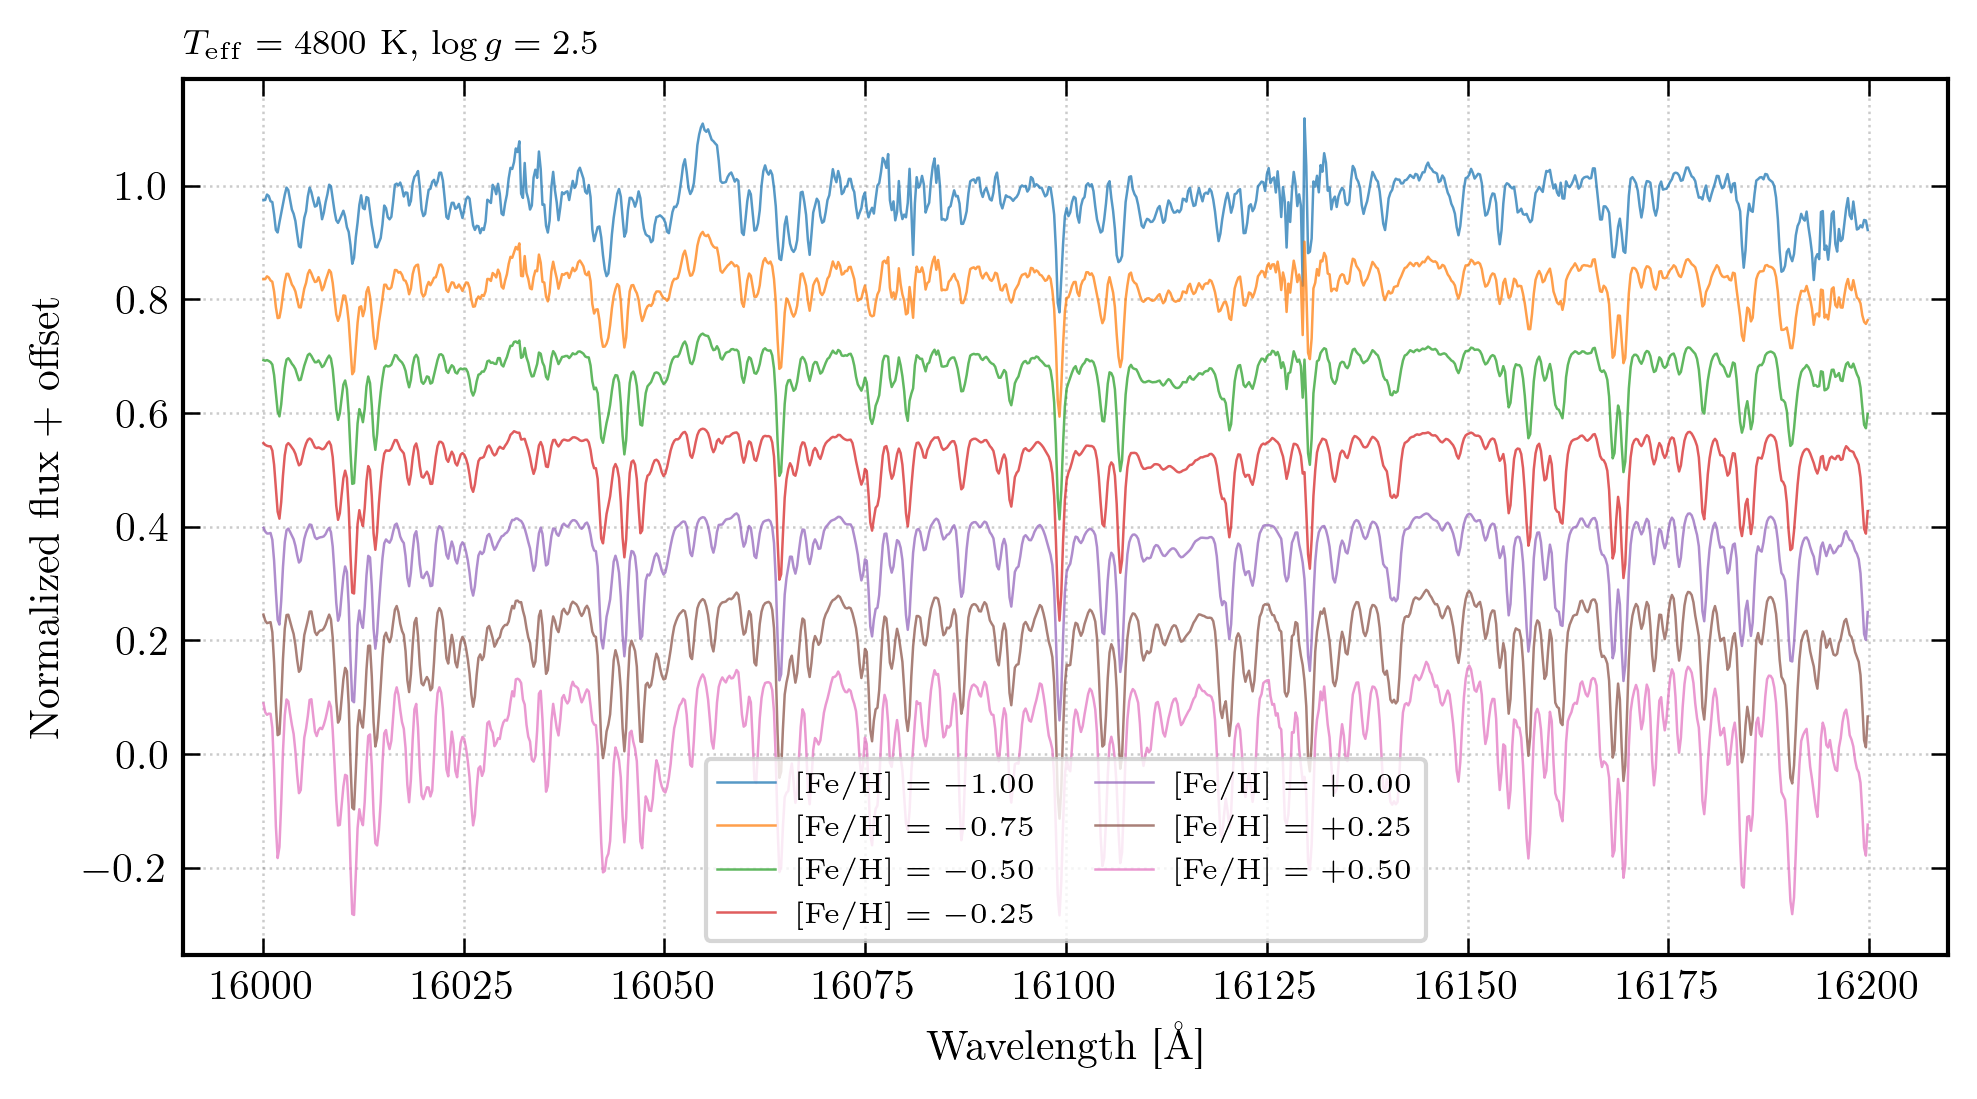

In [10]:
feh_values = np.arange(-1.0, 0.75, 0.25)

ax = plotters.plot_metallicity_sequence(model, feh_values)
plt.show()

### Pinning down what is *different* about Problems 13 and 14

Having seen the metallicity sequence above, before turning to the RGB evolution below it is worth pinning down what is genuinely different about these two ways of moving through label space. Both will change absorption-line depths in the synthetic spectra — but for different physical reasons, and the differential pattern is what lets the Cannon disentangle abundance from temperature/gravity.

- **The metallicity sequence** changes only $[\mathrm{Fe/H}]$ at fixed $T_{\rm eff}$ and $\log g$, so the spectral changes come purely from line-strength scaling: more iron in the photosphere → deeper Fe I lines, with smaller knock-on effects at the Mg I and Si I features (because the [Mg/Fe] and [Si/Fe] ratios are held fixed, so Mg and Si abundances do scale with [Fe/H]).
- **The RGB evolution sequence** holds $[\mathrm{Fe/H}] = 0$ fixed but moves $T_{\rm eff}$ and $\log g$ together along the isochrone. The spectral changes come from temperature-driven ionization, pressure broadening, and the rapid onset of molecular bandheads (CO, OH) at the cool end. Metal-line *strengths* still change because the Boltzmann/Saha balance shifts with $T_{\rm eff}$, but molecular features turn on essentially as a step function around 4500 K — something no metallicity change at fixed $T_{\rm eff}$ can produce.

The Cannon disentangles these two effects through its **per-pixel polynomial coefficients**: the gradient spectra in NB 02 §8a showed that $[\mathrm{Fe/H}]$ has a sharply localized response (only at metal lines), $T_{\rm eff}$ has a broadband response (every line + the continuum slope), and the molecular bandheads have huge $T_{\rm eff}$ gradients but essentially zero $[\mathrm{Fe/H}]$ gradient. So when fitting an unknown spectrum, the Cannon can tell "cool low-gravity star" from "warmer high-gravity metal-rich star" by looking at the *pattern* of which lines are strong, not just the overall metallic depth. This is why both Problems 13 and 14 produce visually similar line-darkening on first glance but the fits in Problem 12 above can recover all five labels simultaneously without degeneracy.

## Problem 14 — RGB Evolution

We extract a $(T_{\rm eff}, \log g)$ track along the red giant branch from a MIST isochrone at $[\mathrm{Fe/H}] = 0$, spanning $\log g = 3.5$ to $0.5$. Synthetic spectra along this track show how the spectrum changes as a star ascends the RGB — both surface gravity *and* effective temperature change in a coupled way along the isochrone (the star simultaneously cools and expands), which is more physically realistic than varying $\log g$ at fixed $T_{\rm eff}$.

**What changes along the RGB.** As the star ascends, three coupled effects modify the spectrum:

1. **Line strengths** vary with temperature through the Boltzmann/Saha balance: cooler stars have stronger neutral metal lines (more Fe I, Mg I, Si I in the ground state) and stronger molecular features (CO, OH).
2. **Pressure broadening** weakens at lower $\log g$. Photospheric gas pressure scales roughly as $P \propto g^{2/3}$ for a giant atmosphere, so descending from $\log g = 3.5$ to $\log g = 0.5$ (a factor of $1000$ in $g$) reduces the photospheric pressure by a factor of $\sim 100$. Collisional (van der Waals) line broadening, which scales linearly with neutral hydrogen pressure, drops by the same factor. The visible signature is that strong line wings narrow and the line cores deepen as the star evolves up the RGB.
3. **Molecular bandheads strengthen rapidly** at low $T_{\rm eff}$: CO is essentially absent above ~5000 K but dominates the spectrum below ~4000 K, producing the well-known spectral type transition along the RGB.

RGB track: 7 points
       Teff     logg
4978.965742 3.486636
4734.960529 2.425872
4706.029820 2.390626
4490.707778 2.006970
4351.967906 1.783654
3913.716087 1.060219
3660.029754 0.630650


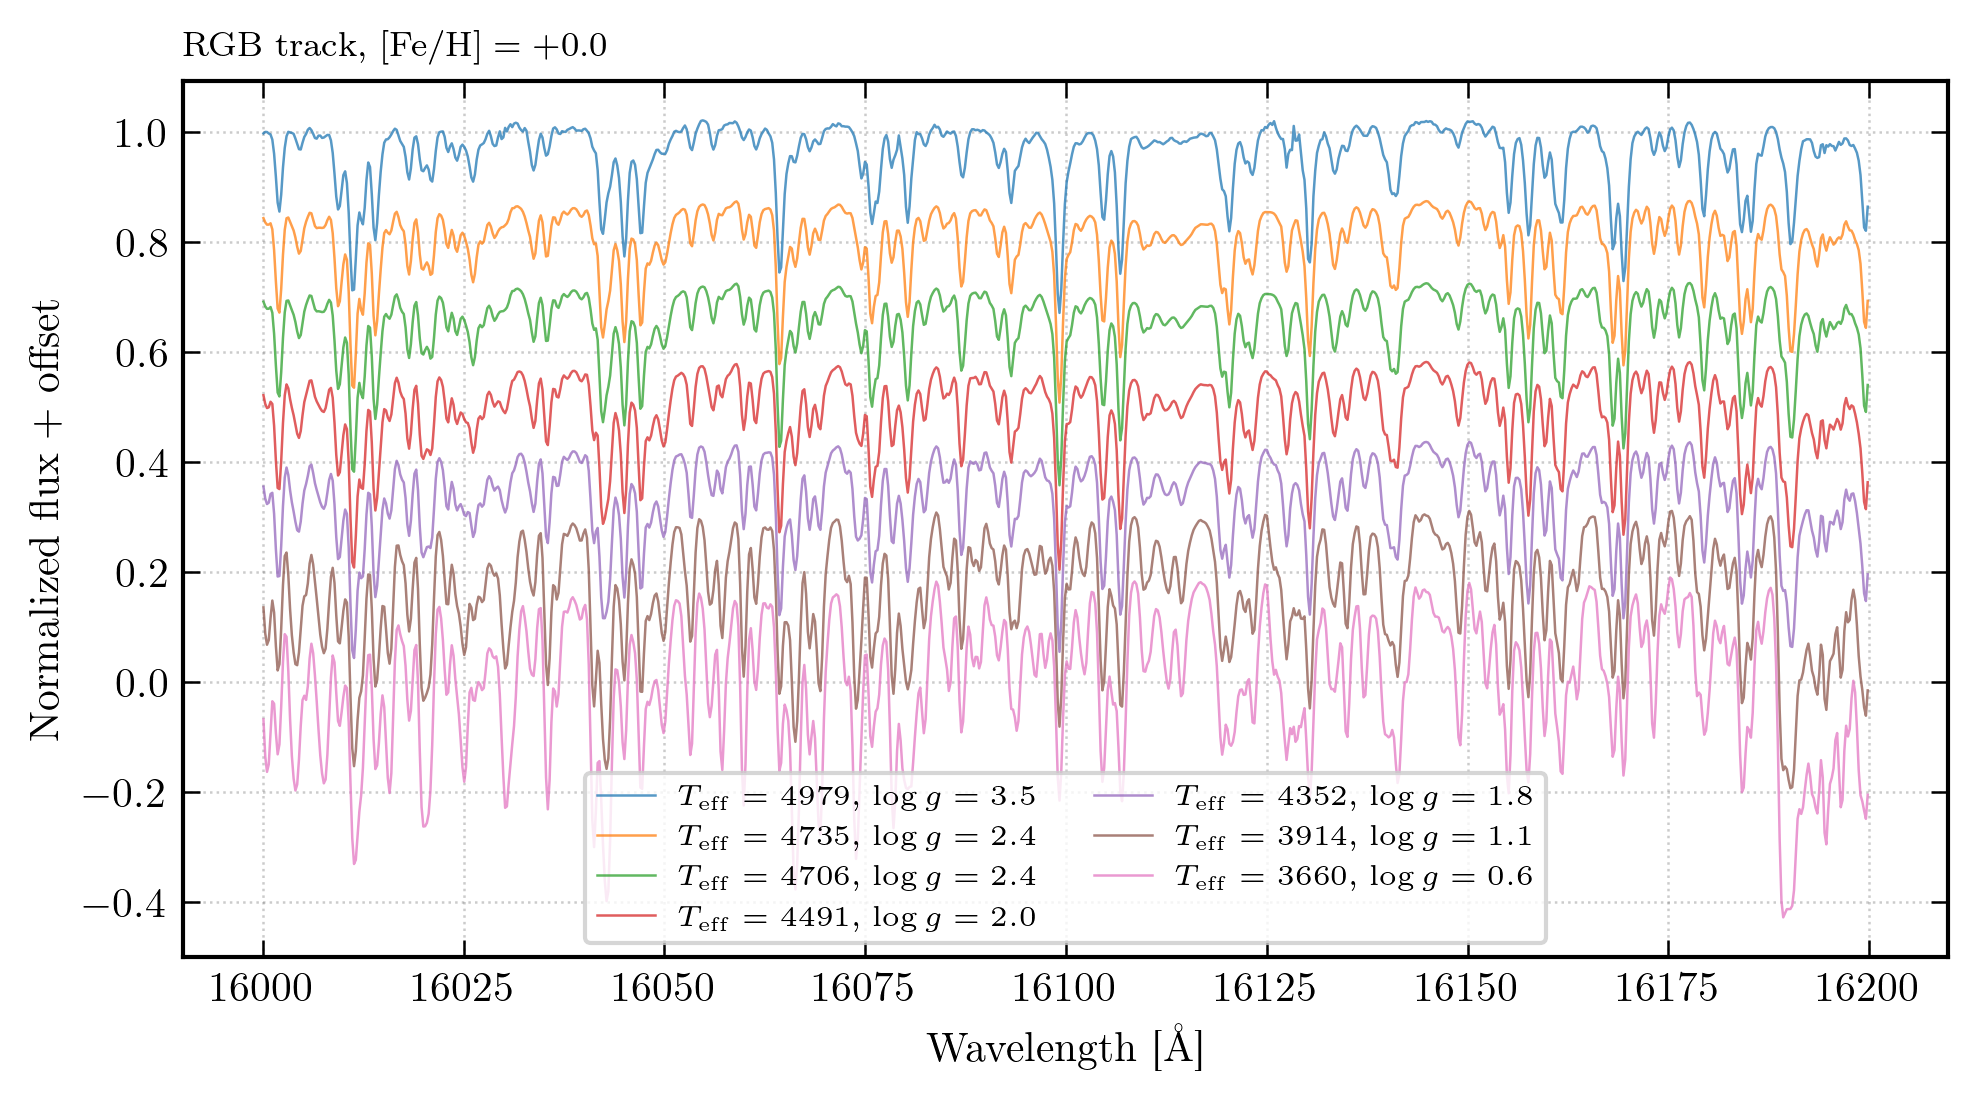

In [11]:
iso_solar = _get_mist_isochrone(6.0, 0.0)

# Extract RGB track: logg decreasing from 3.5 to 0.5
rgb_mask = (iso_solar["logg"] >= 0.5) & (iso_solar["logg"] <= 3.5) & (iso_solar["Teff"] < 5500)
rgb = iso_solar[rgb_mask].sort_values("logg", ascending=False)

# Sample ~7 points along the RGB
n_points = min(7, len(rgb))
step = max(1, len(rgb) // n_points)
rgb_sample = rgb.iloc[::step][:n_points]

print(f"RGB track: {len(rgb_sample)} points")
print(rgb_sample[["Teff", "logg"]].to_string(index=False))

ax = plotters.plot_rgb_evolution(
    model, rgb_sample["Teff"].values, rgb_sample["logg"].values,
)
plt.show()

## Problem 15 — Unresolved Binaries

An unresolved binary produces a composite spectrum — the flux-weighted sum of two stellar spectra. When the Cannon fits this composite with a single-star model, it returns intermediate "effective" labels:

- **$T_{\rm eff}$**: biased high — the secondary (typically cooler) adds red flux, but the combined SED is bluer than the primary alone, pushing the fit toward higher temperature.
- **$\log g$**: may be biased depending on the luminosity ratio — the secondary contributes flux at different line depths.
- **Abundances**: diluted — absorption features from the primary are partially filled in by the secondary's continuum, making lines appear shallower and abundances appear lower.

These biases are discussed in El-Badry et al. (2018), who show that unresolved binaries can mimic metal-poor single stars. Possible mitigations:
1. **Two-component model**: fit a composite spectrum with two sets of labels and a flux ratio.
2. **Binary flagging**: identify candidate binaries via large radial velocity scatter across visits (`vhelio_avg` dispersion) or anomalous position in the Kiel diagram.
3. **Spectral disentangling**: use multi-epoch spectra to separate the two components.